In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

## Diem Thi

In [ ]:
data_diemthi = pd.read_csv('diem_thi_thpt_2024.csv',dtype={'sbd': str})
data_diemthi.head()

,sbd,toan,ngu_van,ngoai_ngu,vat_li,hoa_hoc,sinh_hoc,lich_su,dia_li,gdcd,ma_ngoai_ngu
0,01000001,8.4,6.75,8.0,6.0,5.25,5.0,NaN,NaN,NaN,N1
1,01000002,8.6,8.50,7.2,NaN,NaN,NaN,7.25,6.00,8.00,N1
2,01000003,8.2,8.75,8.2,NaN,NaN,NaN,7.25,7.25,8.75,N1
3,01000004,4.8,8.50,7.4,NaN,NaN,NaN,7.00,6.00,7.50,N1
4,01000005,8.6,9.00,7.8,NaN,NaN,NaN,9.00,8.75,8.50,N1


In [ ]:
provinces = {
    "01": "Hà Nội",
    "02": "TP. Hồ Chí Minh",
    "03": "Hải Phòng",
    "04": "Đà Nẵng",
    "05": "Hà Giang",
    "06": "Cao Bằng",
    "07": "Lai Châu",
    "08": "Lào Cai",
    "09": "Tuyên Quang",
    "10": "Lạng Sơn",
    "11": "Bắc Kạn",
    "12": "Thái Nguyên",
    "13": "Yên Bái",
    "14": "Sơn La",
    "15": "Phú Thọ",
    "16": "Vĩnh Phúc",
    "17": "Quảng Ninh",
    "18": "Bắc Giang",
    "19": "Bắc Ninh",
    "21": "Hải Dương",
    "22": "Hưng Yên",
    "23": "Hòa Bình",
    "24": "Hà Nam",
    "25": "Nam Định",
    "26": "Thái Bình",
    "27": "Ninh Bình",
    "28": "Thanh Hóa",
    "29": "Nghệ An",
    "30": "Hà Tĩnh",
    "31": "Quảng Bình",
    "32": "Quảng Trị",
    "33": "Thừa Thiên-Huế",
    "34": "Quảng Nam",
    "35": "Quảng Ngãi",
    "36": "Kon Tum",
    "37": "Bình Định",
    "38": "Gia Lai",
    "39": "Phú Yên",
    "40": "Đắk Lắk",
    "41": "Khánh Hòa",
    "42": "Lâm Đồng",
    "43": "Bình Phước",
    "44": "Bình Dương",
    "45": "Ninh Thuận",
    "46": "Tây Ninh",
    "47": "Bình Thuận",
    "48": "Đồng Nai",
    "49": "Long An",
    "50": "Đồng Tháp",
    "51": "An Giang",
    "52": "Bà Rịa - Vũng Tàu",
    "53": "Tiền Giang",
    "54": "Kiên Giang",
    "55": "Cần Thơ",
    "56": "Bến Tre",
    "57": "Vĩnh Long",
    "58": "Trà Vinh",
    "59": "Sóc Trăng",
    "60": "Bạc Liêu",
    "61": "Cà Mau",
    "62": "Điện Biên",
    "63": "Đắk Nông",
    "64": "Hậu Giang"
}

In [ ]:
# Extract the first two digits of the ID
data_diemthi['first_two_digits'] = data_diemthi['sbd'].str[:2]

# Map the first two digits to hometown
data_diemthi['hometown'] = data_diemthi['first_two_digits'].map(provinces)

# Drop the intermediate column if you don't need it
data_diemthi = data_diemthi.drop(columns=['first_two_digits'])
data_diemthi.head()

,sbd,toan,ngu_van,ngoai_ngu,vat_li,hoa_hoc,sinh_hoc,lich_su,dia_li,gdcd,ma_ngoai_ngu,hometown
0,01000001,8.4,6.75,8.0,6.0,5.25,5.0,NaN,NaN,NaN,N1,Hà Nội
1,01000002,8.6,8.50,7.2,NaN,NaN,NaN,7.25,6.00,8.00,N1,Hà Nội
2,01000003,8.2,8.75,8.2,NaN,NaN,NaN,7.25,7.25,8.75,N1,Hà Nội
3,01000004,4.8,8.50,7.4,NaN,NaN,NaN,7.00,6.00,7.50,N1,Hà Nội
4,01000005,8.6,9.00,7.8,NaN,NaN,NaN,9.00,8.75,8.50,N1,Hà Nội


In [ ]:
data_diemthi

,sbd,toan,ngu_van,ngoai_ngu,vat_li,hoa_hoc,sinh_hoc,lich_su,dia_li,gdcd,ma_ngoai_ngu,hometown
0,01000001,8.4,6.75,8.0,6.00,5.25,5.0,NaN,NaN,NaN,N1,Hà Nội
1,01000002,8.6,8.50,7.2,NaN,NaN,NaN,7.25,6.00,8.00,N1,Hà Nội
2,01000003,8.2,8.75,8.2,NaN,NaN,NaN,7.25,7.25,8.75,N1,Hà Nội
3,01000004,4.8,8.50,7.4,NaN,NaN,NaN,7.00,6.00,7.50,N1,Hà Nội
4,01000005,8.6,9.00,7.8,NaN,NaN,NaN,9.00,8.75,8.50,N1,Hà Nội
...,...,...,...,...,...,...,...,...,...,...,...,...
1061600,64007282,4.2,6.00,3.0,NaN,NaN,NaN,5.25,6.25,7.50,N1,Hậu Giang
1061601,64007283,5.2,6.00,3.6,NaN,NaN,NaN,6.25,5.75,7.75,N1,Hậu Giang
1061602,64007284,7.2,8.00,7.0,6.25,7.00,8.0,NaN,NaN,NaN,N1,Hậu Giang
1061603,64007285,5.2,5.25,4.4,NaN,NaN,NaN,4.75,6.50,8.75,N1,Hậu Giang


In [ ]:
provinces_by_region = {
    "Miền Bắc": [
        "Hà Nội", "Vĩnh Phúc", "Bắc Ninh", "Quảng Ninh", "Hải Dương", "Hải Phòng",
        "Hưng Yên", "Thái Bình", "Hà Nam", "Nam Định", "Ninh Bình", "Hà Giang",
        "Cao Bằng", "Bắc Kạn", "Tuyên Quang", "Lào Cai", "Yên Bái", "Thái Nguyên",
        "Lạng Sơn", "Bắc Giang", "Phú Thọ", "Điện Biên", "Lai Châu", "Sơn La",
        "Hòa Bình"
    ],
    "Miền Trung": [
        "Thanh Hóa", "Nghệ An", "Hà Tĩnh", "Quảng Bình", "Quảng Trị", "Thừa Thiên-Huế",
        "Đà Nẵng", "Quảng Nam", "Quảng Ngãi", "Bình Định", "Phú Yên", "Khánh Hòa",
        "Ninh Thuận", "Bình Thuận", "Kon Tum", "Gia Lai", "Đắk Lắk", "Đắk Nông",
        "Lâm Đồng"
    ],
    "Miền Nam": [
        "Bình Phước", "Tây Ninh", "Bình Dương", "Đồng Nai", "Bà Rịa - Vũng Tàu",
        "TP. Hồ Chí Minh", "Long An", "Tiền Giang", "Bến Tre", "Trà Vinh", "Vĩnh Long",
        "Đồng Tháp", "An Giang", "Kiên Giang", "Cần Thơ", "Hậu Giang", "Sóc Trăng",
        "Bạc Liêu", "Cà Mau"
    ]
}

In [ ]:
data_diemthi['region'] = data_diemthi['hometown'].apply(lambda x: next((k for k, v in provinces_by_region.items() if x in v), None))
data_diemthi

,sbd,toan,ngu_van,ngoai_ngu,vat_li,hoa_hoc,sinh_hoc,lich_su,dia_li,gdcd,ma_ngoai_ngu,hometown,region
0,01000001,8.4,6.75,8.0,6.00,5.25,5.0,NaN,NaN,NaN,N1,Hà Nội,Miền Bắc
1,01000002,8.6,8.50,7.2,NaN,NaN,NaN,7.25,6.00,8.00,N1,Hà Nội,Miền Bắc
2,01000003,8.2,8.75,8.2,NaN,NaN,NaN,7.25,7.25,8.75,N1,Hà Nội,Miền Bắc
3,01000004,4.8,8.50,7.4,NaN,NaN,NaN,7.00,6.00,7.50,N1,Hà Nội,Miền Bắc
4,01000005,8.6,9.00,7.8,NaN,NaN,NaN,9.00,8.75,8.50,N1,Hà Nội,Miền Bắc
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1061600,64007282,4.2,6.00,3.0,NaN,NaN,NaN,5.25,6.25,7.50,N1,Hậu Giang,Miền Nam
1061601,64007283,5.2,6.00,3.6,NaN,NaN,NaN,6.25,5.75,7.75,N1,Hậu Giang,Miền Nam
1061602,64007284,7.2,8.00,7.0,6.25,7.00,8.0,NaN,NaN,NaN,N1,Hậu Giang,Miền Nam
1061603,64007285,5.2,5.25,4.4,NaN,NaN,NaN,4.75,6.50,8.75,N1,Hậu Giang,Miền Nam


In [ ]:
data_diemthi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1061605 entries, 0 to 1061604
Data columns (total 13 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   sbd           1061605 non-null  object 
 1   toan          1045613 non-null  float64
 2   ngu_van       1050101 non-null  float64
 3   ngoai_ngu     912705 non-null   float64
 4   vat_li        345615 non-null   float64
 5   hoa_hoc       346518 non-null   float64
 6   sinh_hoc      342378 non-null   float64
 7   lich_su       706214 non-null   float64
 8   dia_li        704682 non-null   float64
 9   gdcd          583609 non-null   float64
 10  ma_ngoai_ngu  912705 non-null   object 
 11  hometown      1061605 non-null  object 
 12  region        1061605 non-null  object 
dtypes: float64(9), object(4)
memory usage: 105.3+ MB


In [ ]:
data_diemthi_khac = data_diemthi[[not x for x in (pd.isnull(data_diemthi['ma_ngoai_ngu'].to_list()))] & (data_diemthi['ma_ngoai_ngu'] != 'N1')]
data_diemthi_ta = data_diemthi[data_diemthi['ma_ngoai_ngu'] == 'N1']

<ipython-input-10-6ee3eda362a2>:1: FutureWarning: Logical ops (and, or, xor) between Pandas objects and dtype-less sequences (e.g. list, tuple) are deprecated and will raise in a future version. Wrap the object in a Series, Index, or np.array before operating instead.
  data_diemthi_khac = data_diemthi[[not x for x in (pd.isnull(data_diemthi['ma_ngoai_ngu'].to_list()))] & (data_diemthi['ma_ngoai_ngu'] != 'N1')]


In [ ]:
data_diemthi_ta

,sbd,toan,ngu_van,ngoai_ngu,vat_li,hoa_hoc,sinh_hoc,lich_su,dia_li,gdcd,ma_ngoai_ngu,hometown,region
0,01000001,8.4,6.75,8.0,6.00,5.25,5.0,NaN,NaN,NaN,N1,Hà Nội,Miền Bắc
1,01000002,8.6,8.50,7.2,NaN,NaN,NaN,7.25,6.00,8.00,N1,Hà Nội,Miền Bắc
2,01000003,8.2,8.75,8.2,NaN,NaN,NaN,7.25,7.25,8.75,N1,Hà Nội,Miền Bắc
3,01000004,4.8,8.50,7.4,NaN,NaN,NaN,7.00,6.00,7.50,N1,Hà Nội,Miền Bắc
4,01000005,8.6,9.00,7.8,NaN,NaN,NaN,9.00,8.75,8.50,N1,Hà Nội,Miền Bắc
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1061600,64007282,4.2,6.00,3.0,NaN,NaN,NaN,5.25,6.25,7.50,N1,Hậu Giang,Miền Nam
1061601,64007283,5.2,6.00,3.6,NaN,NaN,NaN,6.25,5.75,7.75,N1,Hậu Giang,Miền Nam
1061602,64007284,7.2,8.00,7.0,6.25,7.00,8.0,NaN,NaN,NaN,N1,Hậu Giang,Miền Nam
1061603,64007285,5.2,5.25,4.4,NaN,NaN,NaN,4.75,6.50,8.75,N1,Hậu Giang,Miền Nam


## Muc Song theo Dia Phuong

In [ ]:
data_GDP5nhom = pd.read_excel('/content/Thu-nhập-bình-quân-đầu-người-SB23.xlsx', skiprows=3, names=['Vùng và địa Phương', 'Bình quân chung', 'Nhóm 1', 'Nhóm 2', 'Nhóm 3', 'Nhóm 4', 'Nhóm 5'])
data_GDP5nhom

,Vùng và địa Phương,Bình quân chung,Nhóm 1,Nhóm 2,Nhóm 3,Nhóm 4,Nhóm 5
0,TỔNG SỐ,4962,1451,2835,4085,5584,10855
1,Đồng bằng sông Hồng,5981,2075,3858,4938,6703,12331
2,Hà Nội,6869,2196,4390,5185,8149,14468
3,Vĩnh Phúc,5463,1903,3492,4249,6468,11230
4,Bắc Ninh,5279,2038,3313,4237,5958,10884
...,...,...,...,...,...,...,...
65,Cần Thơ,5579,1922,3770,4604,5977,11675
66,Hậu Giang,4235,1343,2724,3618,4842,8697
67,Sóc Trăng,3912,1327,2290,3527,4631,7827
68,Bạc Liêu,4755,1573,2885,4003,5316,10056


In [ ]:
data_maytinh = pd.read_excel('/content/Tỷ-lệ-hộ-có-máy-tính-phân-theo-địa-phương-SB23.xlsx', skiprows=2, names=['Vùng và địa Phương', 'Tỷ lệ hộ có máy tính (%)'])
data_maytinh

,Vùng và địa Phương,Tỷ lệ hộ có máy tính (%)
0,CẢ NƯỚC,28.3
1,Hà Nội,53.2
2,Vĩnh Phúc,34.1
3,Bắc Ninh,31.3
4,Quảng Ninh,17.1
...,...,...
59,Cần Thơ,32.1
60,Hậu Giang,15.8
61,Sóc Trăng,18.0
62,Bạc Liêu,15.0


In [ ]:
data_hongheo = pd.read_excel('/content/Tỷ-lệ-hộ-nghèo-theo-Chuẩn-nghèo-đa-chiều-phân-theo-địa-phương-SB23.xlsx', skiprows=2, names=['Vùng và địa Phương', 'Tỷ lệ hộ nghèo theo Chuẩn nghèo đa chiều (%)'])
data_hongheo

,Vùng và địa Phương,Tỷ lệ hộ nghèo theo Chuẩn nghèo đa chiều (%)
0,TỔNG SỐ,3.37
1,Đồng bằng sông Hồng,0.70
2,Hà Nội,0.10
3,Vĩnh Phúc,0.73
4,Bắc Ninh,1.00
...,...,...
65,Cần Thơ,0.87
66,Hậu Giang,3.88
67,Sóc Trăng,4.95
68,Bạc Liêu,4.29


## Merge

In [ ]:
result = data_maytinh.merge(data_hongheo, how='left', on='Vùng và địa Phương')
result = result.merge(data_GDP5nhom, how='left', on='Vùng và địa Phương')
result

,Vùng và địa Phương,Tỷ lệ hộ có máy tính (%),Tỷ lệ hộ nghèo theo Chuẩn nghèo đa chiều (%),Bình quân chung,Nhóm 1,Nhóm 2,Nhóm 3,Nhóm 4,Nhóm 5
0,CẢ NƯỚC,28.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Hà Nội,53.2,0.10,6869.0,2196.0,4390.0,5185.0,8149.0,14468.0
2,Vĩnh Phúc,34.1,0.73,5463.0,1903.0,3492.0,4249.0,6468.0,11230.0
3,Bắc Ninh,31.3,1.00,5279.0,2038.0,3313.0,4237.0,5958.0,10884.0
4,Quảng Ninh,17.1,1.09,5295.0,1745.0,3202.0,4135.0,5382.0,12041.0
...,...,...,...,...,...,...,...,...,...
59,Cần Thơ,32.1,0.87,5579.0,1922.0,3770.0,4604.0,5977.0,11675.0
60,Hậu Giang,15.8,3.88,4235.0,1343.0,2724.0,3618.0,4842.0,8697.0
61,Sóc Trăng,18.0,4.95,3912.0,1327.0,2290.0,3527.0,4631.0,7827.0
62,Bạc Liêu,15.0,4.29,4755.0,1573.0,2885.0,4003.0,5316.0,10056.0


In [ ]:
data_diemthi_ta_tb = data_diemthi_ta.groupby('hometown', as_index=False).agg({'ngoai_ngu': 'mean'})#.sort_values(by='ngoai_ngu', ascending=False)
data_diemthi_ta_tb

,hometown,ngoai_ngu
0,An Giang,5.523866
1,Bà Rịa - Vũng Tàu,6.220373
2,Bình Dương,6.650717
3,Bình Phước,5.271228
4,Bình Thuận,5.207606
...,...,...
58,Đà Nẵng,6.100905
59,Đắk Lắk,4.650480
60,Đắk Nông,4.342882
61,Đồng Nai,5.664179


In [ ]:
merged_df = pd.merge(result, data_diemthi_ta_tb, right_on='hometown', left_on='Vùng và địa Phương')
merged_df

,Vùng và địa Phương,Tỷ lệ hộ có máy tính (%),Tỷ lệ hộ nghèo theo Chuẩn nghèo đa chiều (%),Bình quân chung,Nhóm 1,Nhóm 2,Nhóm 3,Nhóm 4,Nhóm 5,hometown,ngoai_ngu
0,Hà Nội,53.2,0.10,6869.0,2196.0,4390.0,5185.0,8149.0,14468.0,Hà Nội,6.185658
1,Vĩnh Phúc,34.1,0.73,5463.0,1903.0,3492.0,4249.0,6468.0,11230.0,Vĩnh Phúc,6.071411
2,Bắc Ninh,31.3,1.00,5279.0,2038.0,3313.0,4237.0,5958.0,10884.0,Bắc Ninh,5.969605
3,Quảng Ninh,17.1,1.09,5295.0,1745.0,3202.0,4135.0,5382.0,12041.0,Quảng Ninh,5.730062
4,Hải Dương,28.2,0.71,5336.0,2030.0,3800.0,4636.0,5856.0,10392.0,Hải Dương,5.509531
...,...,...,...,...,...,...,...,...,...,...,...
58,Cần Thơ,32.1,0.87,5579.0,1922.0,3770.0,4604.0,5977.0,11675.0,Cần Thơ,5.433886
59,Hậu Giang,15.8,3.88,4235.0,1343.0,2724.0,3618.0,4842.0,8697.0,Hậu Giang,4.548082
60,Sóc Trăng,18.0,4.95,3912.0,1327.0,2290.0,3527.0,4631.0,7827.0,Sóc Trăng,4.650903
61,Bạc Liêu,15.0,4.29,4755.0,1573.0,2885.0,4003.0,5316.0,10056.0,Bạc Liêu,5.084351


## Regression/Correlaton

#### Ty le ho co may tinh

Regression Equation: ngoai_ngu = 0.04 * Tỷ lệ hộ có máy tính + 4.20
Correlation Coefficient: 0.66


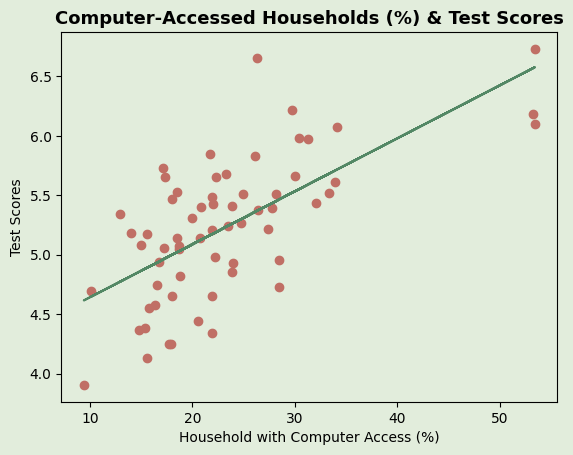

There is a positive correlation between the percentage of households with computers and the foreign language proficiency.


In [ ]:
# Define the dependent and independent variables
X = merged_df['Tỷ lệ hộ có máy tính (%)']
y = merged_df['ngoai_ngu']

# Calculate the means of X and y
mean_X = X.mean()
mean_y = y.mean()

# Calculate the numerator and denominator of the slope
numerator = ((X - mean_X) * (y - mean_y)).sum()
denominator = ((X - mean_X) ** 2).sum()

# Calculate the slope and intercept
slope = numerator / denominator
intercept = mean_y - slope * mean_X

# Print the regression equation
print(f"Regression Equation: ngoai_ngu = {slope:.2f} * Tỷ lệ hộ có máy tính + {intercept:.2f}")

# Calculate the correlation coefficient
correlation = np.corrcoef(X, y)[0, 1]
print(f"Correlation Coefficient: {correlation:.2f}")

# Plot the regression line
plt.scatter(X, y, color='#c06f65',alpha=0.8)  # Change the scatter plot dots to #d49154
plt.plot(X, slope * X + intercept, color='#538865')  # Change the line to black
plt.xlabel('Household with Computer Access (%)')
plt.ylabel('Test Scores')
plt.title('Computer-Accessed Households (%) & Test Scores', fontsize=13, weight='bold')

# Set the background color of the plot
plt.gca().set_facecolor('#e2eddc')  # Changes the inside of the plot area
plt.gcf().set_facecolor('#e2eddc')  # Changes the outside (figure) background

plt.show()

# Conclusion
if correlation > 0:
    print("There is a positive correlation between the percentage of households with computers and the foreign language proficiency.")
elif correlation < 0:
    print("There is a negative correlation between the percentage of households with computers and the foreign language proficiency.")
else:
    print("There is no correlation between the percentage of households with computers and the foreign language proficiency.")

#### Ty le ho ngheo

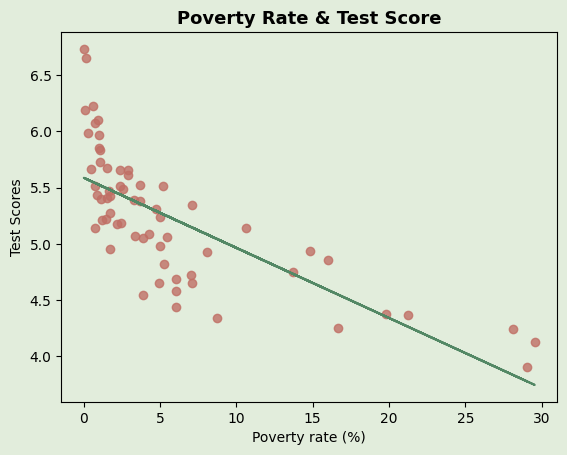

Regression Equation: ngoai_ngu = -0.06 * Tỷ lệ hộ nghèo + 5.59
Correlation Coefficient: -0.74
There is a negative correlation between the percentage of households in poverty and the foreign language proficiency.


In [ ]:
# Define the dependent and independent variables
X = merged_df['Tỷ lệ hộ nghèo theo Chuẩn nghèo đa chiều (%)']
y = merged_df['ngoai_ngu']

# Calculate the means of X and y
mean_X = X.mean()
mean_y = y.mean()

# Calculate the numerator and denominator of the slope
numerator = ((X - mean_X) * (y - mean_y)).sum()
denominator = ((X - mean_X) ** 2).sum()

# Calculate the slope and intercept
slope = numerator / denominator
intercept = mean_y - slope * mean_X

# Calculate the correlation coefficient
correlation = np.corrcoef(X, y)[0, 1]

# Plot the regression line
plt.scatter(X, y, color='#c06f65',alpha=0.8)  # Change the scatter plot dots to #d49154
plt.plot(X, slope * X + intercept, color='#538865')  # Change the line to black
plt.xlabel('Poverty rate (%)')
plt.ylabel('Test Scores')
plt.title('Poverty Rate & Test Score',fontsize=13, weight='bold')


# Set the background color of the plot
plt.gca().set_facecolor('#e2eddc')  # Changes the inside of the plot area
plt.gcf().set_facecolor('#e2eddc')  # Changes the outside (figure) background

plt.show()
# Print the regression equation and correlation coefficient
print(f"Regression Equation: ngoai_ngu = {slope:.2f} * Tỷ lệ hộ nghèo + {intercept:.2f}")
print(f"Correlation Coefficient: {correlation:.2f}")

# Conclusion
if correlation > 0:
    print("There is a positive correlation between the percentage of households in poverty and the foreign language proficiency.")
elif correlation < 0:
    print("There is a negative correlation between the percentage of households in poverty and the foreign language proficiency.")
else:
    print("There is no correlation between the percentage of households in poverty and the foreign language proficiency.")

#### GDP Binh Quan Chung

Regression Equation: ngoai_ngu = 0.0004 * Bình quân chung + 3.43
Correlation Coefficient: 0.85
There is a positive correlation between the GDP and the foreign language proficiency.


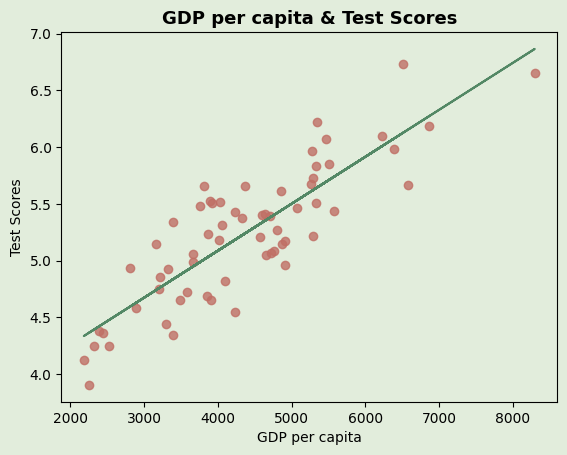

In [ ]:
# Define the dependent and independent variables
X = merged_df['Bình quân chung']
y = merged_df['ngoai_ngu']

# Calculate the means of X and y
mean_X = X.mean()
mean_y = y.mean()

# Calculate the numerator and denominator of the slope
numerator = ((X - mean_X) * (y - mean_y)).sum()
denominator = ((X - mean_X) ** 2).sum()

# Calculate the slope and intercept
slope = numerator / denominator
intercept = mean_y - slope * mean_X

# Calculate the correlation coefficient
correlation = np.corrcoef(X, y)[0, 1]

# Plot the regression line



# Plot the regression line
plt.scatter(X, y, color='#c06f65',alpha=0.8)  # Change the scatter plot dots to #d49154
plt.plot(X, slope * X + intercept, color='#538865')  # Change the line to black
plt.xlabel('GDP per capita')
plt.ylabel('Test Scores')
plt.title('GDP per capita & Test Scores',fontsize=13, weight='bold')


# Set the background color of the plot
plt.gca().set_facecolor('#e2eddc')  # Changes the inside of the plot area
plt.gcf().set_facecolor('#e2eddc')  # Changes the outside (figure) background


# Print the regression equation and correlation coefficient
print(f"Regression Equation: ngoai_ngu = {slope:.4f} * Bình quân chung + {intercept:.2f}")
print(f"Correlation Coefficient: {correlation:.2f}")

# Conclusion
if correlation > 0:
    print("There is a positive correlation between the GDP and the foreign language proficiency.")
elif correlation < 0:
    print("There is a negative correlation between the GDP and the foreign language proficiency.")
else:
    print("There is no correlation between the GDP and the foreign language proficiency.")

## Barchart

#### Skip không thi/ lấy điểm IELTS sth sth

#### mean tung vung (nay chắc k xài làm gì)

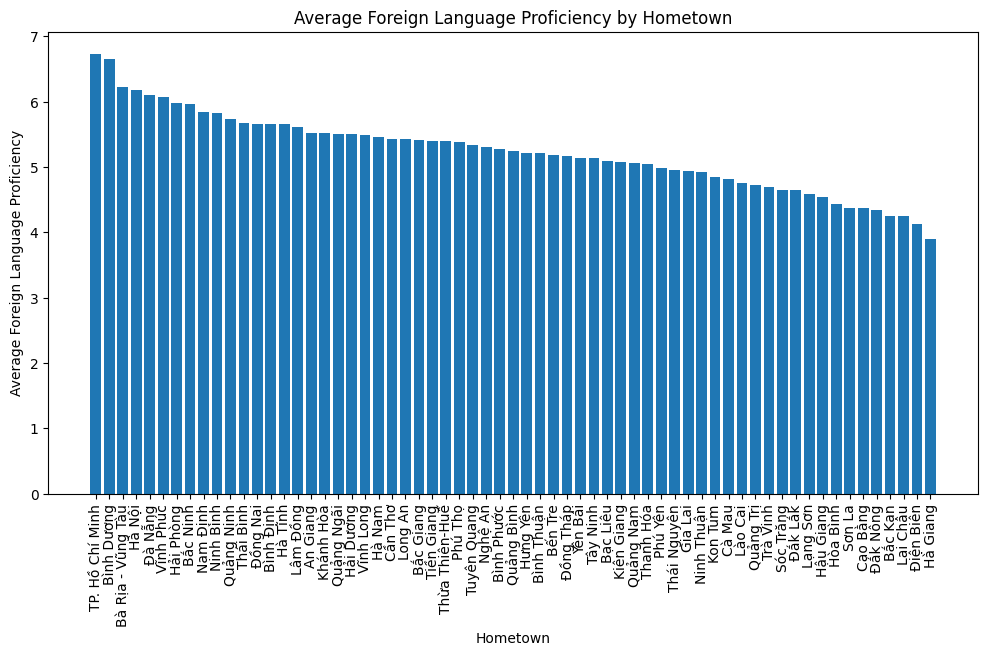

In [ ]:
# Sort the DataFrame in descending order based on the 'ngoai_ngu' column
sorted_data_diemthi_ta_tb = data_diemthi_ta_tb.sort_values(by='ngoai_ngu', ascending=False)

# Plot the bar chart
plt.figure(figsize=(12, 6))
plt.bar(sorted_data_diemthi_ta_tb['hometown'], sorted_data_diemthi_ta_tb['ngoai_ngu'])
plt.xlabel('Hometown')
plt.ylabel('Average Foreign Language Proficiency')
plt.title('Average Foreign Language Proficiency by Hometown')
plt.xticks(rotation=90)
plt.show()

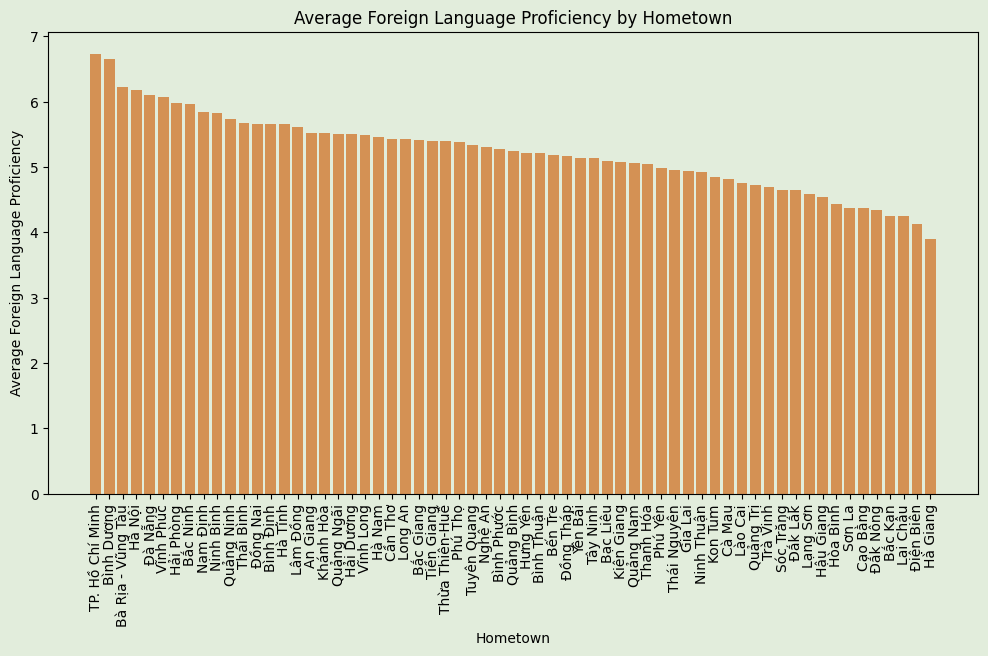

In [ ]:
# Sort the DataFrame in descending order based on the 'ngoai_ngu' column
sorted_data_diemthi_ta_tb = data_diemthi_ta_tb.sort_values(by='ngoai_ngu', ascending=False)

# Create the figure and axis objects
fig, ax = plt.subplots(figsize=(12, 6))

# Set the bar colors
ax.bar(sorted_data_diemthi_ta_tb['hometown'], sorted_data_diemthi_ta_tb['ngoai_ngu'], color='#d49154')

# Set labels and title
ax.set_xlabel('Hometown')
ax.set_ylabel('Average Foreign Language Proficiency')
ax.set_title('Average Foreign Language Proficiency by Hometown')

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)

# Set the background color of the plot (inside the graph)
ax.set_facecolor('#e2eddc')

# Set the background color of the entire figure (outside the graph)
fig.patch.set_facecolor('#e2eddc')

# Display the plot
plt.show()


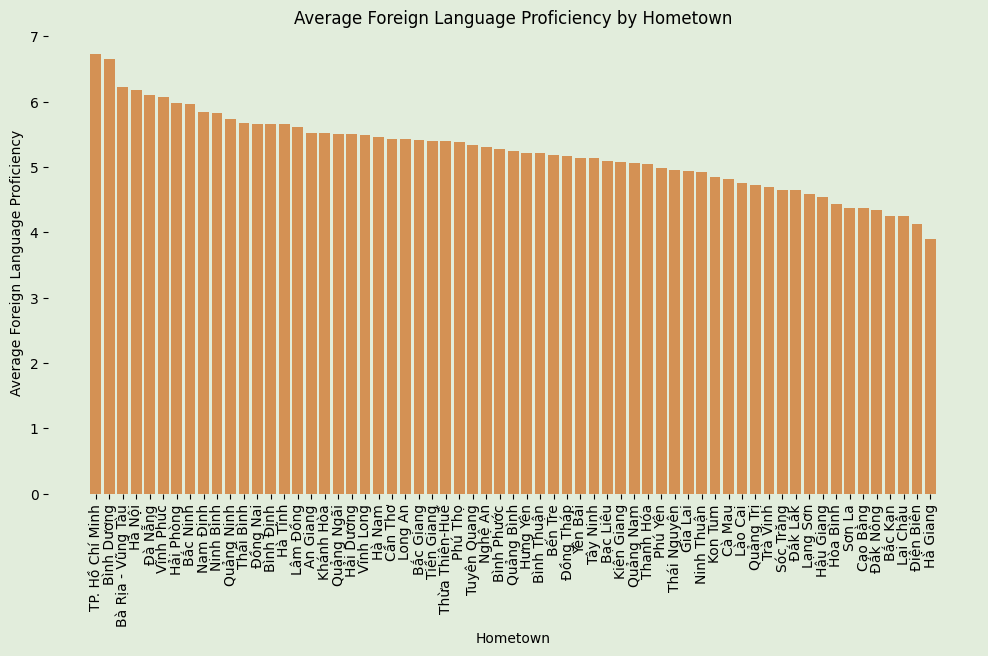

In [ ]:
# Sort the DataFrame in descending order based on the 'ngoai_ngu' column
sorted_data_diemthi_ta_tb = data_diemthi_ta_tb.sort_values(by='ngoai_ngu', ascending=False)

# Plot the bar chart
fig, ax = plt.subplots(figsize=(12, 6))
plt.bar(sorted_data_diemthi_ta_tb['hometown'], sorted_data_diemthi_ta_tb['ngoai_ngu'], color='#d49154')  # Set bar color to #d49154
plt.xlabel('Hometown')
plt.ylabel('Average Foreign Language Proficiency')
plt.title('Average Foreign Language Proficiency by Hometown')

# Set the background color
plt.gca().set_facecolor('#e2eddc')  # Set background color to #e2eddc
# Set the background color of the entire figure (outside the graph)
fig.patch.set_facecolor('#e2eddc')
# Rotate x-axis labels for better readability
plt.xticks(rotation=90)

# Make the x and y axes invisible
plt.gca().spines['top'].set_color('none')
plt.gca().spines['right'].set_color('none')
plt.gca().spines['left'].set_color('none')
plt.gca().spines['bottom'].set_color('none')

# Display the plot
plt.show()


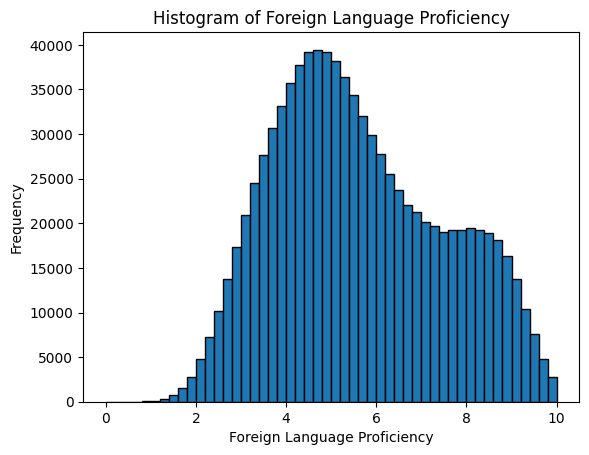

In [ ]:
count = pd.DataFrame(data_diemthi_ta['ngoai_ngu'].value_counts().sort_index())
categories = count.index

# Plot the histogram
plt.hist(data_diemthi_ta['ngoai_ngu'], bins=categories, edgecolor='black') # Create histogram with kernel density estimate
plt.xlabel('Foreign Language Proficiency')
plt.ylabel('Frequency')
plt.title('Histogram of Foreign Language Proficiency')
plt.show()

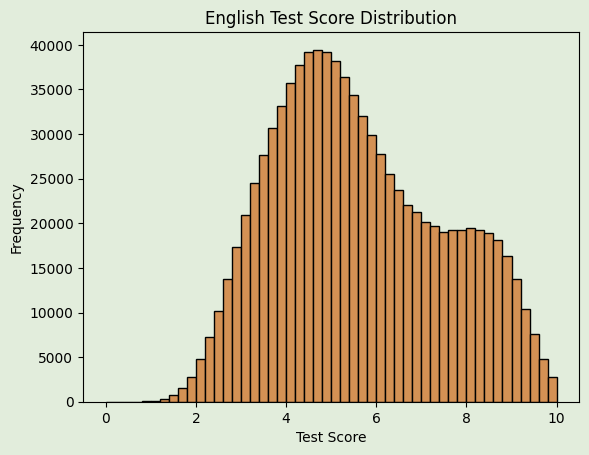

In [ ]:
# Count the occurrences of each value in 'ngoai_ngu' and sort by index
count = pd.DataFrame(data_diemthi_ta['ngoai_ngu'].value_counts().sort_index())
categories = count.index

# Create the figure and axis objects
fig, ax = plt.subplots()

# Plot the histogram with custom bar and edge colors
ax.hist(data_diemthi_ta['ngoai_ngu'], bins=categories, color='#d49154', edgecolor='black')

# Set labels and title
ax.set_xlabel('Test Score')
ax.set_ylabel('Frequency')
ax.set_title('English Test Score Distribution')

# Set the background color of the plot (inside the graph)
ax.set_facecolor('#e2eddc')

# Set the background color of the entire figure (outside the graph)
fig.patch.set_facecolor('#e2eddc')

# Display the plot
plt.show()


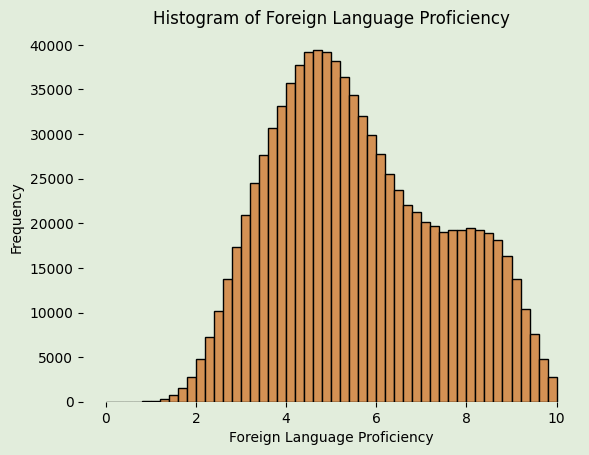

In [ ]:
# Count the occurrences of each value in 'ngoai_ngu' and sort by index
count = pd.DataFrame(data_diemthi_ta['ngoai_ngu'].value_counts().sort_index())
categories = count.index

# Create the figure and axis objects
fig, ax = plt.subplots()

# Plot the histogram with custom bar and edge colors
ax.hist(data_diemthi_ta['ngoai_ngu'], bins=categories, color='#d49154', edgecolor='black')

# Set labels and title
ax.set_xlabel('Foreign Language Proficiency')
ax.set_ylabel('Frequency')
ax.set_title('Histogram of Foreign Language Proficiency')

# Set the background color of the plot (inside the graph)
ax.set_facecolor('#e2eddc')

# Set the background color of the entire figure (outside the graph)
fig.patch.set_facecolor('#e2eddc')

# Make the x and y axes invisible
ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['bottom'].set_color('none')

# Display the plot
plt.show()


## Theo miền

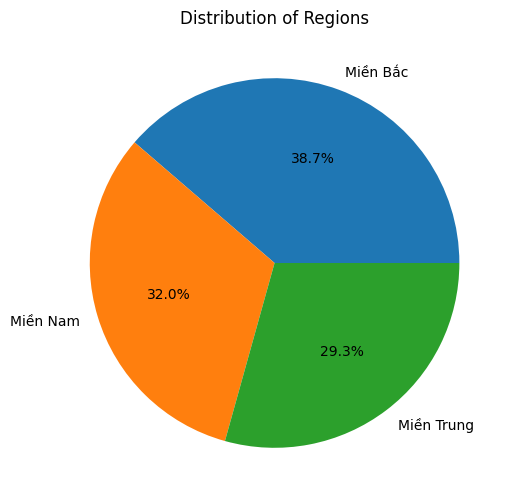

In [ ]:
# Count the number of occurrences of each region
region_counts = data_diemthi_ta['region'].value_counts()

# Plot the pie chart
plt.figure(figsize=(8, 6))
plt.pie(region_counts, labels=region_counts.index, autopct='%1.1f%%')
plt.title('Distribution of Regions')
plt.show()

<Figure size 1000x600 with 0 Axes>

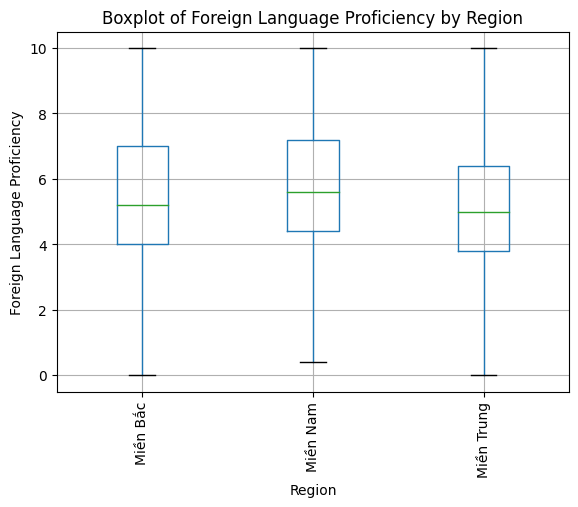

In [ ]:
plt.figure(figsize=(10, 6))
data_diemthi_ta.boxplot(column='ngoai_ngu', by='region')
plt.xlabel('Region')
plt.ylabel('Foreign Language Proficiency')
plt.title('Boxplot of Foreign Language Proficiency by Region')
plt.suptitle('')  # Remove the default title
plt.xticks(rotation=90)
plt.show()

## Diem 10/0


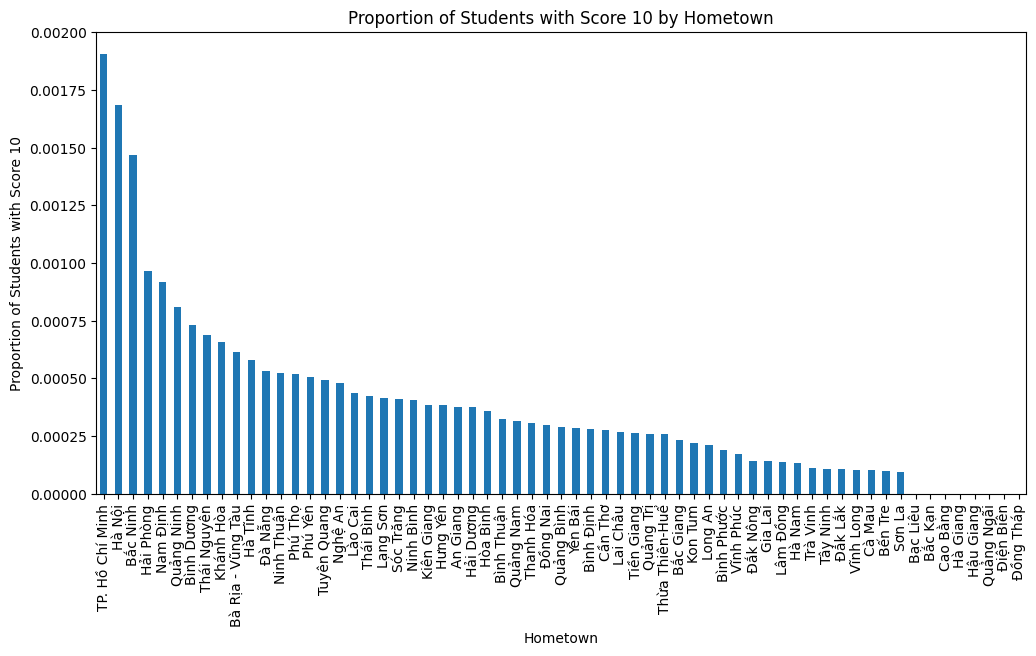

In [ ]:
# Calculate the proportion of students with a score of 10 for each hometown
proportion_10 = data_diemthi_ta[data_diemthi_ta['ngoai_ngu'] == 10]['hometown'].value_counts() / data_diemthi_ta['hometown'].value_counts()

# Sort the proportions in descending order
proportion_10_sorted = proportion_10.sort_values(ascending=False)

# Plot the bar chart
plt.figure(figsize=(12, 6))
proportion_10_sorted.plot(kind='bar')
plt.xlabel('Hometown')
plt.ylabel('Proportion of Students with Score 10')
plt.title('Proportion of Students with Score 10 by Hometown')
plt.xticks(rotation=90)
plt.show()

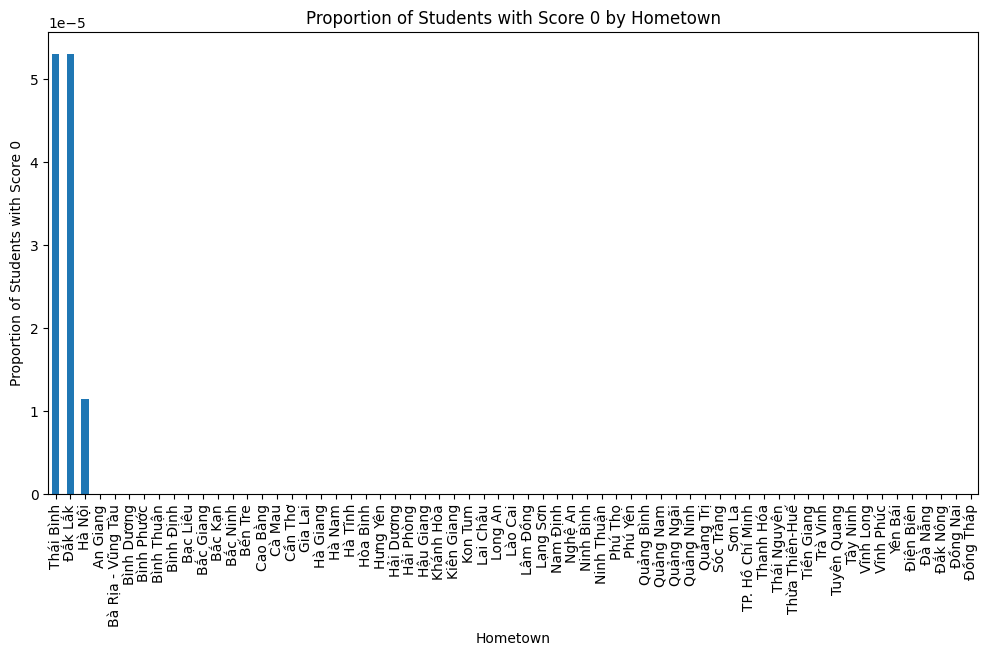

In [ ]:
# Calculate the proportion of students with a score of 10 for each hometown
proportion_0 = data_diemthi_ta[data_diemthi_ta['ngoai_ngu'] == 0]['hometown'].value_counts() / data_diemthi_ta['hometown'].value_counts()

# Sort the proportions in descending order
proportion_0_sorted = proportion_0.sort_values(ascending=False)

# Plot the bar chart
plt.figure(figsize=(12, 6))
proportion_0_sorted.plot(kind='bar')
plt.xlabel('Hometown')
plt.ylabel('Proportion of Students with Score 0')
plt.title('Proportion of Students with Score 0 by Hometown')
plt.xticks(rotation=90)
plt.show()

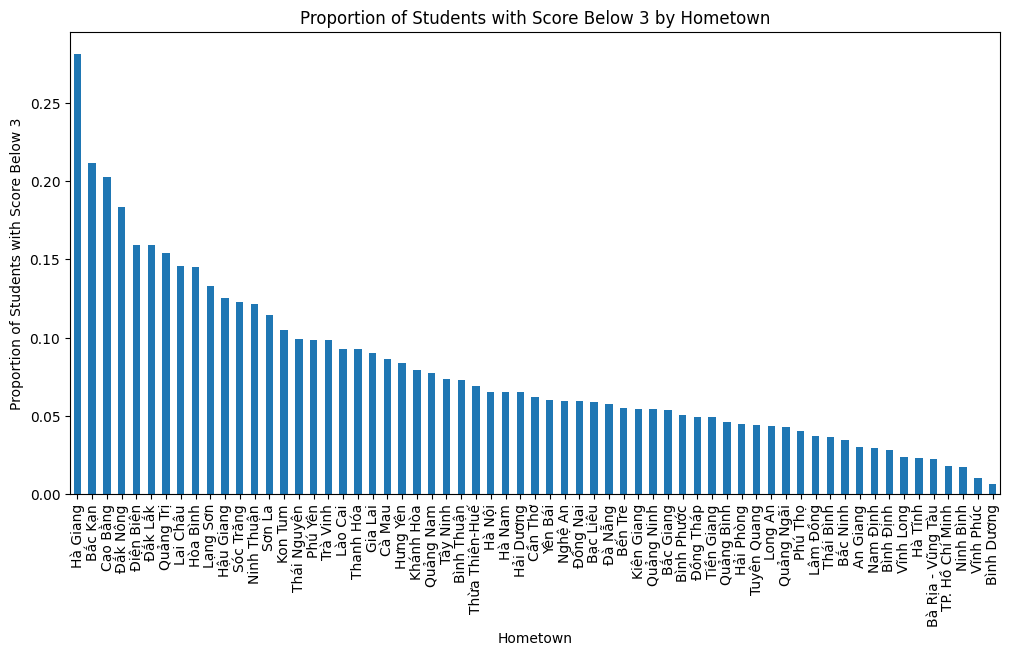

In [ ]:
# Calculate the proportion of students with a score below 3 for each hometown
proportion_below3 = data_diemthi_ta[data_diemthi_ta['ngoai_ngu'] < 3]['hometown'].value_counts() / data_diemthi_ta['hometown'].value_counts()

# Sort the proportions in descending order
proportion_below3_sorted = proportion_below3.sort_values(ascending=False)

# Plot the bar chart
plt.figure(figsize=(12, 6))
proportion_below3_sorted.plot(kind='bar')
plt.xlabel('Hometown')
plt.ylabel('Proportion of Students with Score Below 3')
plt.title('Proportion of Students with Score Below 3 by Hometown')
plt.xticks(rotation=90)
plt.show()

### theo region


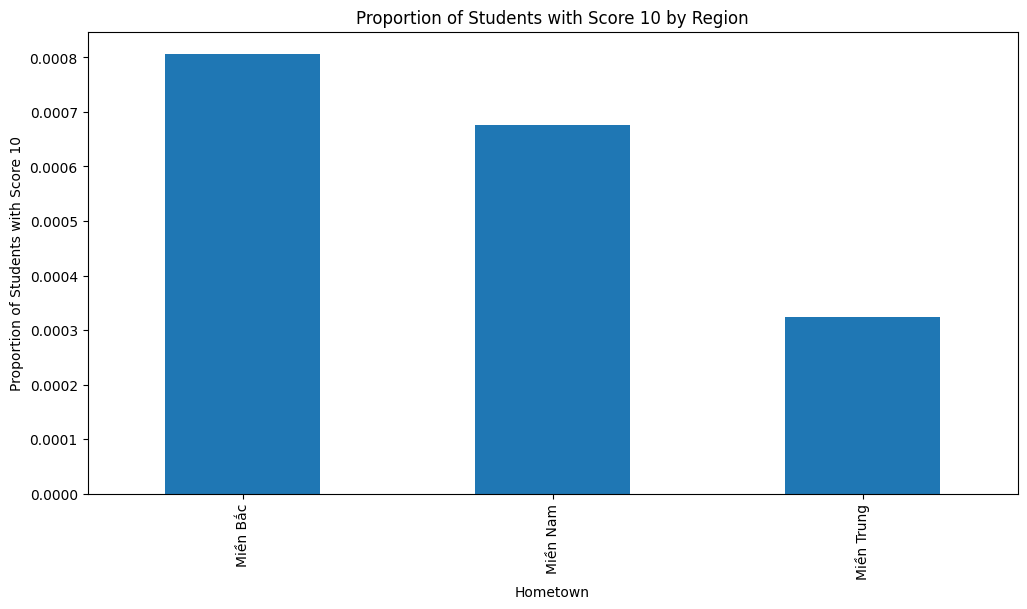

In [ ]:
proportion_10_by_region = data_diemthi_ta[data_diemthi_ta['ngoai_ngu'] == 10]['region'].value_counts() / data_diemthi_ta['region'].value_counts()

# Sort the proportions in descending order
proportion_10_by_region_sorted = proportion_10_by_region.sort_values(ascending=False)

# Plot the bar chart
plt.figure(figsize=(12, 6))
proportion_10_by_region_sorted.plot(kind='bar')
plt.xlabel('Hometown')
plt.ylabel('Proportion of Students with Score 10')
plt.title('Proportion of Students with Score 10 by Region')
plt.xticks(rotation=90)
plt.show()

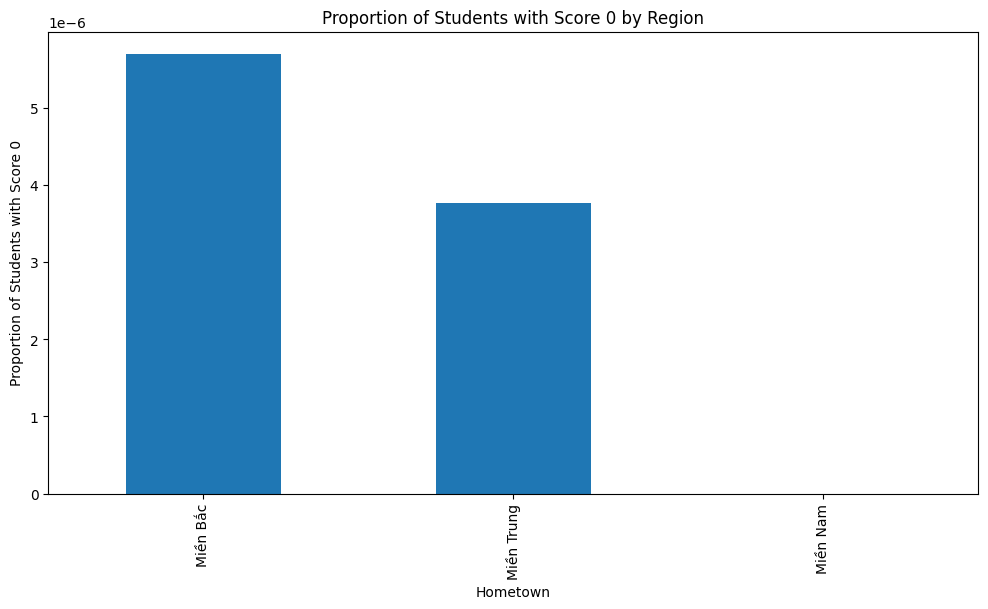

In [ ]:
proportion_0_by_region = data_diemthi_ta[data_diemthi_ta['ngoai_ngu'] == 0]['region'].value_counts() / data_diemthi_ta['region'].value_counts()

# Sort the proportions in descending order
proportion_0_by_region_sorted = proportion_0_by_region.sort_values(ascending=False)

# Plot the bar chart
plt.figure(figsize=(12, 6))
proportion_0_by_region_sorted.plot(kind='bar')
plt.xlabel('Hometown')
plt.ylabel('Proportion of Students with Score 0')
plt.title('Proportion of Students with Score 0 by Region')
plt.xticks(rotation=90)
plt.show()

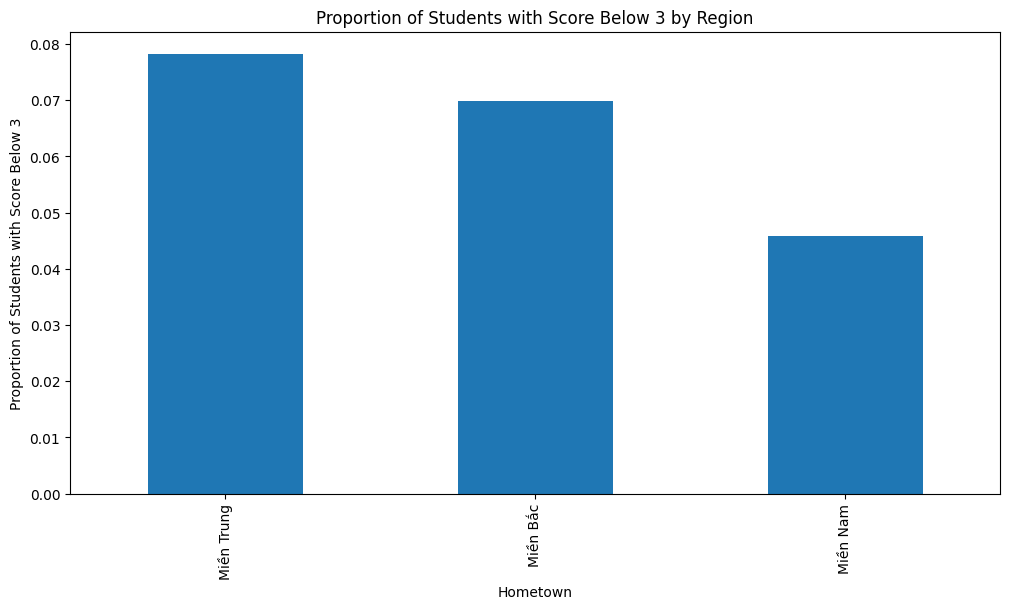

In [ ]:
# Calculate the proportion of students with a score below 3 for each region
proportion_below3_by_region = data_diemthi_ta[data_diemthi_ta['ngoai_ngu'] < 3]['region'].value_counts() / data_diemthi_ta['region'].value_counts()

# Sort the proportions in descending order
proportion_below3_by_region_sorted = proportion_below3_by_region.sort_values(ascending=False)

# Plot the bar chart
plt.figure(figsize=(12, 6))
proportion_below3_by_region_sorted.plot(kind='bar')
plt.xlabel('Hometown')
plt.ylabel('Proportion of Students with Score Below 3')
plt.title('Proportion of Students with Score Below 3 by Region')
plt.xticks(rotation=90)
plt.show()

## Diem thi tren/ dưới tb

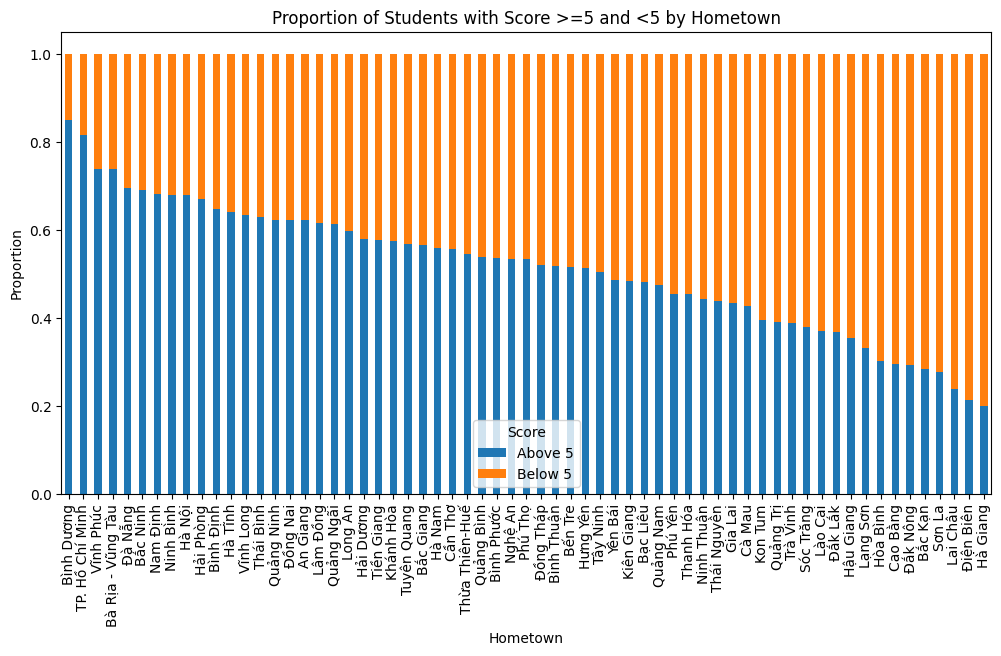

In [ ]:
# Calculate the proportion of students who score >=5 and <5
proportion_above5 = data_diemthi_ta[data_diemthi_ta['ngoai_ngu'] >= 5]['hometown'].value_counts() / data_diemthi_ta['hometown'].value_counts()
proportion_below5 = data_diemthi_ta[data_diemthi_ta['ngoai_ngu'] < 5]['hometown'].value_counts() / data_diemthi_ta['hometown'].value_counts()

# Sort the proportions in descending order
proportion_above5_sorted = proportion_above5.sort_values(ascending=False)
proportion_below5_sorted = proportion_below5.sort_values(ascending=True)

# Create a DataFrame with the proportions
proportions_df = pd.DataFrame({'Above 5': proportion_above5_sorted, 'Below 5': proportion_below5_sorted})

# Plot the stacked bar chart
proportions_df.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.xlabel('Hometown')
plt.ylabel('Proportion')
plt.title('Proportion of Students with Score >=5 and <5 by Hometown')
plt.xticks(rotation=90)
plt.legend(title='Score')
plt.show()

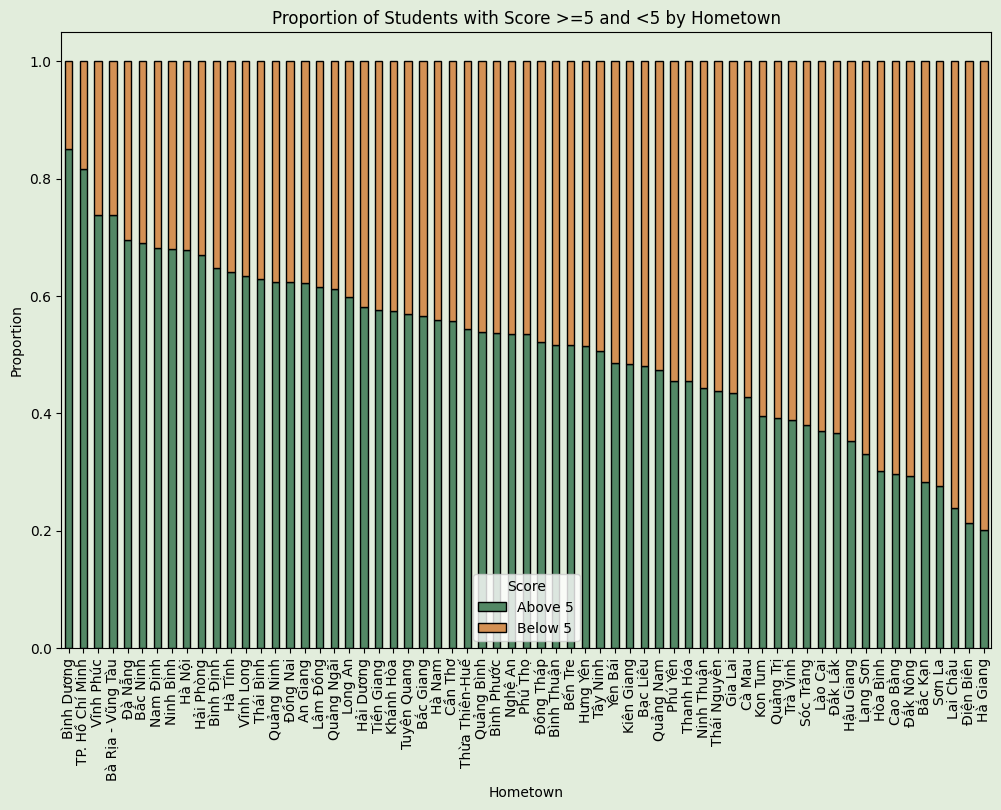

In [ ]:
# Calculate the proportion of students who score >=5 and <5
proportion_above5 = data_diemthi_ta[data_diemthi_ta['ngoai_ngu'] >= 5]['hometown'].value_counts() / data_diemthi_ta['hometown'].value_counts()
proportion_below5 = data_diemthi_ta[data_diemthi_ta['ngoai_ngu'] < 5]['hometown'].value_counts() / data_diemthi_ta['hometown'].value_counts()

# Sort the proportions in descending order
proportion_above5_sorted = proportion_above5.sort_values(ascending=False)
proportion_below5_sorted = proportion_below5.sort_values(ascending=True)
colors = ['#538865', '#d49154']
# Create a DataFrame with the proportions
proportions_df = pd.DataFrame({'Above 5': proportion_above5_sorted, 'Below 5': proportion_below5_sorted})
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#e2eddc')  # Background color outside the graph
ax.set_facecolor('#e2eddc')         # Background color inside the graph
proportions_df.plot(kind='bar', stacked=True, color=colors, ax=ax,edgecolor='black')
plt.xlabel('Hometown')
plt.ylabel('Proportion')
plt.title('Proportion of Students with Score >=5 and <5 by Hometown')
plt.xticks(rotation=90)
plt.legend(title='Score')
plt.show()

<ipython-input-38-a857d8208014>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data_diemthi_ta.groupby(['region', pd.cut(data_diemthi_ta['ngoai_ngu'], bins=[0, 5, 10])]).size().unstack()


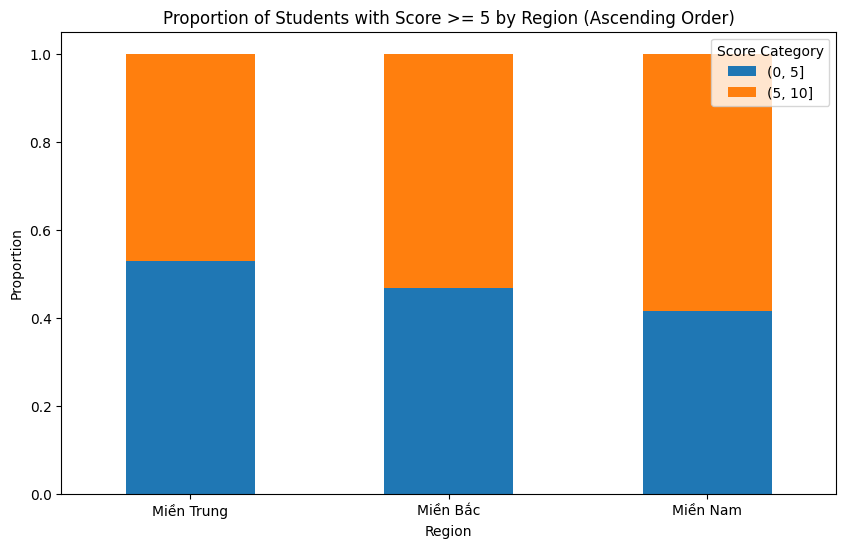

In [ ]:
# Group the data by region and score category
grouped_data = data_diemthi_ta.groupby(['region', pd.cut(data_diemthi_ta['ngoai_ngu'], bins=[0, 5, 10])]).size().unstack()

# Calculate the proportions
proportions = grouped_data.div(grouped_data.sum(axis=1), axis=0)

# Sort the proportions in ascending order based on the proportion above 5
proportions_sorted = proportions.sort_values(by=(pd.Interval(5, 10, closed='right')))

# Plot the stacked bar chart
proportions_sorted.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.xlabel('Region')
plt.ylabel('Proportion')
plt.title('Proportion of Students with Score >= 5 by Region (Ascending Order)')
plt.legend(title='Score Category')
plt.xticks(rotation=0)
plt.show()


<ipython-input-39-51246f384766>:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data_diemthi_ta.groupby(['region', pd.cut(data_diemthi_ta['ngoai_ngu'], bins=[0, 5, 10])]).size().unstack()


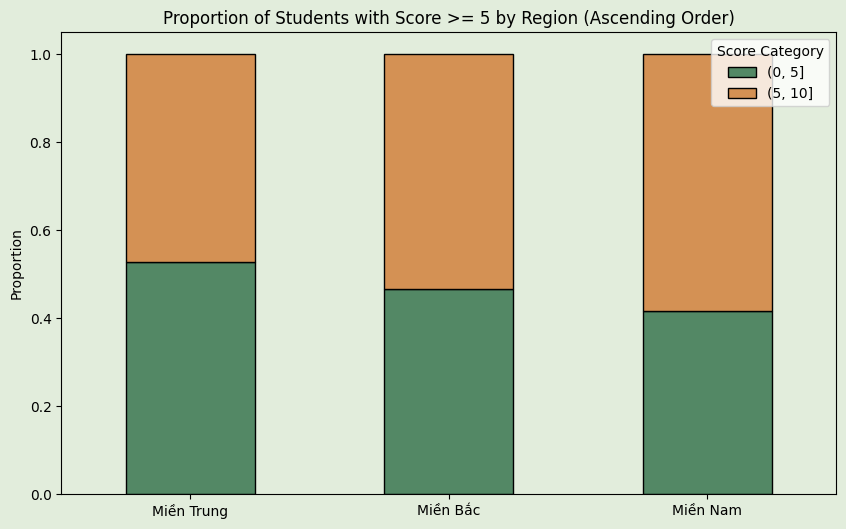

In [ ]:
import matplotlib.pyplot as plt

# Group the data by region and score category
grouped_data = data_diemthi_ta.groupby(['region', pd.cut(data_diemthi_ta['ngoai_ngu'], bins=[0, 5, 10])]).size().unstack()

# Calculate the proportions
proportions = grouped_data.div(grouped_data.sum(axis=1), axis=0)

# Sort the proportions in ascending order based on the proportion above 5
proportions_sorted = proportions.sort_values(by=(pd.Interval(5, 10, closed='right')))

# Create the plot
ax = proportions_sorted.plot(kind='bar', stacked=True,edgecolor='black' ,figsize=(10, 6), color=['#538865', '#d49154'])

# Customize background color
plt.gcf().set_facecolor('#e2eddc')  # Set the figure background color
ax.set_facecolor('#e2eddc')  # Set the axes background color

# Add labels and title
plt.xlabel('')
plt.ylabel('Proportion')
plt.title('Proportion of Students with Score >= 5 by Region (Ascending Order)')
plt.legend(title='Score Category')
plt.xticks(rotation=0)

# Show the plot
plt.show()
